#### Paper:

Intro: <br>
Hundreds of bird/aircraft collisions (bird strike) occur every year. Bird strike is not only fatal for the bird but can also cause severe damage to the aircraft and in extreme cases result in a crash. I wanted to find out if there was any correlation between bird strike incidents and time of year. Roughly 40 percent of all birds are migratory, and bird migration is at its peak during spring and autumn. I predicted that bird strikes would peak during these heavy migration times. <br>
The data set I am using is a list of all aircraft/wildlife collisions reported to the US Federal Aviation Administration (FAA) between 1990 and 1997. I will be looking at the date, specifically the month, the strike was reported and the number of birds that were struck as well as the number of birds seen. 

Analysis: <br>
I wanted to find out which month had the most bird strikes and additionally look at which month had the most bird sightings. Since the dataset I chose had a record of all wildlife strikes from 1990-1997, I first had to separate out only the bird strikes for use. I then had to convert the date values to datetime and create a separate column for months. I also had to convert the bird strike and bird seen data into a usable format: float. Several values were listed as ranges, and I wanted to take the middle of the range for use. Also, some values were listed as "Over 100" so the non-numerical text had to be removed too. I added up the total bird strikes/sightings for each month and displayed them as a bar plot. 

Conclusion: <br>
While there does seem to be an increase of bird strikes during autumn as I had predicted, the highest spikes were more in late summer and there were much less reported bird strikes in spring. The relation of bird strikes to migration times is unclear. It would be worth looking into data of all flights that occurred during those years to check if the increase of bird collisions during the summer months was due to increase of flights instead. It also might be worth looking into more recent data sets as recording technology has improved. 


References: <br>
Aircraft Wildlife Strike Data: Search Tool - FAA Wildlife Strike Database. Available at https://datahub.transportation.gov/Aviation/Aircraft-Wildlife-Strike-Data-Search-Tool-FAA-Wild/jhay-dgxy. Retrieval date: Feb 4, 2012. <br>
Denny, M. (2016). *Long Hops: Making Sense of Bird Migration.* University of Hawai’i Press. http://www.jstor.org.montgomerycollege.idm.oclc.org/stable/j.ctvvn0tt.5 <br>
El-Sayed, A. F. (2019). *Bird Strike in Aviation: Statistics, Analysis and Management.* John Wiley & Sons Ltd. DOI:10.1002/9781119529835

In [460]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("birds.csv")
df.head()

,opid,operator,atype,remarks,phase_of_flt,ac_mass,num_engs,date,time_of_day,state,height,speed,effect,sky,species,birds_seen,birds_struck
0,AAL,AMERICAN AIRLINES,MD-80,NO DAMAGE,Descent,4.0,2.0,9/30/1990 0:00:00,Night,IL,7000.0,250.0,NaN,No Cloud,UNKNOWN BIRD - MEDIUM,NaN,1
1,USA,US AIRWAYS,FK-28-4000,"2 BIRDS, NO DAMAGE.",Climb,4.0,2.0,11/29/1993 0:00:00,Day,MD,10.0,140.0,NaN,No Cloud,UNKNOWN BIRD - MEDIUM,2-10,2-10
2,AAL,AMERICAN AIRLINES,B-727-200,NaN,Approach,4.0,3.0,8/13/1993 0:00:00,Day,TN,400.0,140.0,NaN,Some Cloud,UNKNOWN BIRD - SMALL,2-10,1
3,AAL,AMERICAN AIRLINES,MD-82,NaN,Climb,4.0,2.0,10/7/1993 0:00:00,Day,VA,100.0,200.0,NaN,Overcast,UNKNOWN BIRD - SMALL,NaN,1
4,AAL,AMERICAN AIRLINES,MD-82,NO DAMAGE,Climb,4.0,2.0,9/25/1993 0:00:00,Day,SC,50.0,170.0,NaN,Some Cloud,UNKNOWN BIRD - SMALL,2-10,1


In [461]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   opid          19302 non-null  object 
 1   operator      19302 non-null  object 
 2   atype         19302 non-null  object 
 3   remarks       16516 non-null  object 
 4   phase_of_flt  17519 non-null  object 
 5   ac_mass       18018 non-null  float64
 6   num_engs      17995 non-null  float64
 7   date          19302 non-null  object 
 8   time_of_day   17225 non-null  object 
 9   state         18431 non-null  object 
 10  height        16109 non-null  float64
 11  speed         12294 non-null  float64
 12  effect        1973 non-null   object 
 13  sky           15723 non-null  object 
 14  species       19302 non-null  object 
 15  birds_seen    4764 non-null   object 
 16  birds_struck  19263 non-null  object 
dtypes: float64(4), object(13)
memory usage: 2.5+ MB


#### Displays all different values in species column. Display has been commented in post to save space.

In [462]:
speciesList = df["species"].drop_duplicates()
#display(speciesList.to_string())

#### Removes all non bird entries from dataset.

In [463]:
notBirds = ["RABBITS", "AMERICAN ALLIGATOR", "RED FOX", "OPOSSUM", "ARMADILLO", "WHITE-TAILED DEER", "BATS",
"TURTLES", "CATTLE", "WOODCHUCK", "FOXES", "STRIPED SKUNK", "CANIDS", "EASTERN BOX TURTLE", "RIVER OTTER", "MOOSE",
"COYOTE", "DOMESTIC CAT", "UNKNOWN MAMMAL", "DEER", "WAPITI (ELK)", "DOMESTIC DOG", "MULE DEER", "RACCOON",
"MUSKRAT", "PRONGHORN", "HOARY BAT", "FLORIDA SOF SHELL TURTLE", "EASTERN COTTONTAIL", "NORTH AMERICANPORCUPINE", "CARIBOU"]
df = df[~df["species"].isin(notBirds)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18812 entries, 0 to 19301
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   opid          18812 non-null  object 
 1   operator      18812 non-null  object 
 2   atype         18812 non-null  object 
 3   remarks       16043 non-null  object 
 4   phase_of_flt  17107 non-null  object 
 5   ac_mass       17622 non-null  float64
 6   num_engs      17603 non-null  float64
 7   date          18812 non-null  object 
 8   time_of_day   16834 non-null  object 
 9   state         17945 non-null  object 
 10  height        15733 non-null  float64
 11  speed         12201 non-null  float64
 12  effect        1792 non-null   object 
 13  sky           15528 non-null  object 
 14  species       18812 non-null  object 
 15  birds_seen    4683 non-null   object 
 16  birds_struck  18786 non-null  object 
dtypes: float64(4), object(13)
memory usage: 2.6+ MB


#### Creates a sepate column for month.

In [464]:
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18812 entries, 0 to 19301
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   opid          18812 non-null  object        
 1   operator      18812 non-null  object        
 2   atype         18812 non-null  object        
 3   remarks       16043 non-null  object        
 4   phase_of_flt  17107 non-null  object        
 5   ac_mass       17622 non-null  float64       
 6   num_engs      17603 non-null  float64       
 7   date          18812 non-null  datetime64[ns]
 8   time_of_day   16834 non-null  object        
 9   state         17945 non-null  object        
 10  height        15733 non-null  float64       
 11  speed         12201 non-null  float64       
 12  effect        1792 non-null   object        
 13  sky           15528 non-null  object        
 14  species       18812 non-null  object        
 15  birds_seen    4683 non-null   object     

In [465]:
df["month"] = df["date"].dt.month
df.head()

,opid,operator,atype,remarks,phase_of_flt,ac_mass,num_engs,date,time_of_day,state,height,speed,effect,sky,species,birds_seen,birds_struck,month
0,AAL,AMERICAN AIRLINES,MD-80,NO DAMAGE,Descent,4.0,2.0,1990-09-30,Night,IL,7000.0,250.0,NaN,No Cloud,UNKNOWN BIRD - MEDIUM,NaN,1,9
1,USA,US AIRWAYS,FK-28-4000,"2 BIRDS, NO DAMAGE.",Climb,4.0,2.0,1993-11-29,Day,MD,10.0,140.0,NaN,No Cloud,UNKNOWN BIRD - MEDIUM,2-10,2-10,11
2,AAL,AMERICAN AIRLINES,B-727-200,NaN,Approach,4.0,3.0,1993-08-13,Day,TN,400.0,140.0,NaN,Some Cloud,UNKNOWN BIRD - SMALL,2-10,1,8
3,AAL,AMERICAN AIRLINES,MD-82,NaN,Climb,4.0,2.0,1993-10-07,Day,VA,100.0,200.0,NaN,Overcast,UNKNOWN BIRD - SMALL,NaN,1,10
4,AAL,AMERICAN AIRLINES,MD-82,NO DAMAGE,Climb,4.0,2.0,1993-09-25,Day,SC,50.0,170.0,NaN,Some Cloud,UNKNOWN BIRD - SMALL,2-10,1,9


#### Takes mean for any range values in "birds_stuck" and converts all values to float.

In [466]:
df["birds_struck2"] = df["birds_struck"].str.extract("(\d+)$",expand=False).astype(float)
df["birds_struck"] = df["birds_struck"].str.extract("(\d+)",expand=False).astype(float)
df["birds_struck"] = df[["birds_struck","birds_struck2"]].mean(axis=1)
df = df.drop(columns = ["birds_struck2"])
df.head()

,opid,operator,atype,remarks,phase_of_flt,ac_mass,num_engs,date,time_of_day,state,height,speed,effect,sky,species,birds_seen,birds_struck,month
0,AAL,AMERICAN AIRLINES,MD-80,NO DAMAGE,Descent,4.0,2.0,1990-09-30,Night,IL,7000.0,250.0,NaN,No Cloud,UNKNOWN BIRD - MEDIUM,NaN,1.0,9
1,USA,US AIRWAYS,FK-28-4000,"2 BIRDS, NO DAMAGE.",Climb,4.0,2.0,1993-11-29,Day,MD,10.0,140.0,NaN,No Cloud,UNKNOWN BIRD - MEDIUM,2-10,6.0,11
2,AAL,AMERICAN AIRLINES,B-727-200,NaN,Approach,4.0,3.0,1993-08-13,Day,TN,400.0,140.0,NaN,Some Cloud,UNKNOWN BIRD - SMALL,2-10,1.0,8
3,AAL,AMERICAN AIRLINES,MD-82,NaN,Climb,4.0,2.0,1993-10-07,Day,VA,100.0,200.0,NaN,Overcast,UNKNOWN BIRD - SMALL,NaN,1.0,10
4,AAL,AMERICAN AIRLINES,MD-82,NO DAMAGE,Climb,4.0,2.0,1993-09-25,Day,SC,50.0,170.0,NaN,Some Cloud,UNKNOWN BIRD - SMALL,2-10,1.0,9


#### Same as above but for "birds_seen".

In [467]:
df["birds_seen2"] = df["birds_seen"].str.extract("(\d+)$",expand=False).astype(float)
df["birds_seen"] = df["birds_seen"].str.extract("(\d+)",expand=False).astype(float)
df["birds_seen"] = df[["birds_seen","birds_seen2"]].mean(axis=1)
df = df.drop(columns = ["birds_seen2"])
df.head()

,opid,operator,atype,remarks,phase_of_flt,ac_mass,num_engs,date,time_of_day,state,height,speed,effect,sky,species,birds_seen,birds_struck,month
0,AAL,AMERICAN AIRLINES,MD-80,NO DAMAGE,Descent,4.0,2.0,1990-09-30,Night,IL,7000.0,250.0,NaN,No Cloud,UNKNOWN BIRD - MEDIUM,NaN,1.0,9
1,USA,US AIRWAYS,FK-28-4000,"2 BIRDS, NO DAMAGE.",Climb,4.0,2.0,1993-11-29,Day,MD,10.0,140.0,NaN,No Cloud,UNKNOWN BIRD - MEDIUM,6.0,6.0,11
2,AAL,AMERICAN AIRLINES,B-727-200,NaN,Approach,4.0,3.0,1993-08-13,Day,TN,400.0,140.0,NaN,Some Cloud,UNKNOWN BIRD - SMALL,6.0,1.0,8
3,AAL,AMERICAN AIRLINES,MD-82,NaN,Climb,4.0,2.0,1993-10-07,Day,VA,100.0,200.0,NaN,Overcast,UNKNOWN BIRD - SMALL,NaN,1.0,10
4,AAL,AMERICAN AIRLINES,MD-82,NO DAMAGE,Climb,4.0,2.0,1993-09-25,Day,SC,50.0,170.0,NaN,Some Cloud,UNKNOWN BIRD - SMALL,6.0,1.0,9


#### Displays total birds struck per month.

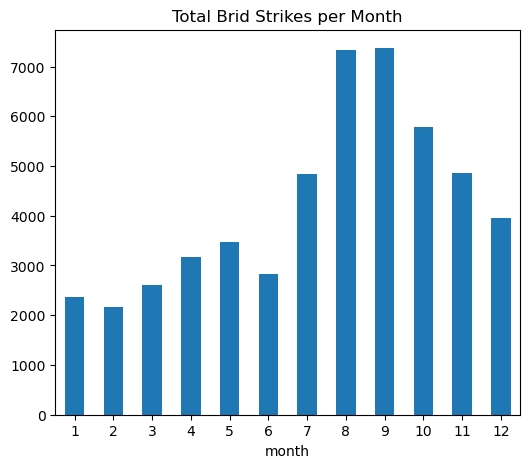

In [484]:
birdsStruckPerMonth = df.groupby("month")["birds_struck"].sum()
plt.figure(figsize = (6,5))
birdsStruckPerMonth.plot(kind = "bar")
plt.xticks(rotation = 0)
plt.title("Total Brid Strikes per Month")
plt.savefig("birdStrikes.png", bbox_inches = "tight")
plt.show()

#### Displays total birds seen per month.

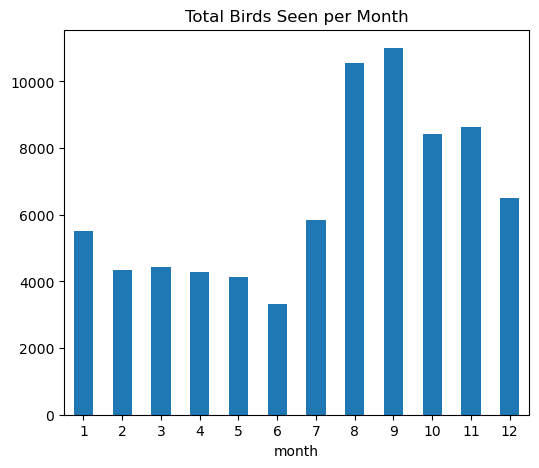

In [485]:
birdsSeenPerMonth = df.groupby("month")["birds_seen"].sum()
plt.figure(figsize = (6,5))
birdsSeenPerMonth.plot(kind = "bar")
plt.xticks(rotation = 0)
plt.title("Total Birds Seen per Month")
plt.savefig("birdSeen.png", bbox_inches = "tight")
plt.show()